In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import PowerTransformer
from matplotlib.dates import MonthLocator, DateFormatter, YearLocator
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Dense, InputLayer, LSTM
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import os

In [2]:
train = pd.read_csv('data/DailyDelhiClimateTrain.csv')
test = pd.read_csv('data/DailyDelhiClimateTest.csv')

In [3]:
file_path = os.path.join('..','..', 'data', 'Merged_data', 'eaglei_noaa_era5_full.parquet')
df = pd.read_parquet(file_path)

In [4]:
df.head()

,,,fips_code,customers_out,datetime,YEAR,NAME,STUSPS,Pct_Buried_Lines,neighbors,Subregion,centroid_longitude,...,event_count Heat,event_count Fire,event_count Wind,event_count Ocean,event_count Other,t2m,u10,v10,sf,tp
time,latitude,longitude,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,32.5,-86.6,1001.0,2.083333,2019-01-01 00:00:00,2019,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.0,0.0,0.0,0.0,293.362183,0.961334,3.989058,0.0,0.003854
2019-01-01 06:00:00,32.5,-86.6,1001.0,0.000000,2019-01-01 06:00:00,2019,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.0,0.0,0.0,0.0,292.707092,0.872604,2.616913,0.0,0.001672
2019-01-01 12:00:00,32.5,-86.6,1001.0,0.125000,2019-01-01 12:00:00,2019,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.0,0.0,0.0,0.0,289.616882,0.323883,-2.613495,0.0,0.004106
2019-01-01 18:00:00,32.5,-86.6,1001.0,0.958333,2019-01-01 18:00:00,2019,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.0,0.0,0.0,0.0,290.067749,0.286743,-0.936096,0.0,0.004162
2019-01-02 00:00:00,32.5,-86.6,1001.0,0.000000,2019-01-02 00:00:00,2019,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.0,0.0,0.0,0.0,289.477539,0.208411,-1.321411,0.0,0.009568


In [71]:
county_fips = 48491

df_county = df[(df['fips_code']==county_fips) & (df['datetime']<datetime.datetime(2021,1,1))]
del df
df_county

,,,fips_code,customers_out,datetime,YEAR,NAME,STUSPS,Pct_Buried_Lines,neighbors,Subregion,centroid_longitude,...,event_count Heat,event_count Fire,event_count Wind,event_count Ocean,event_count Other,t2m,u10,v10,sf,tp
time,latitude,longitude,,,,,,,,,,,,,,,,,,,,,
2019-01-01 06:00:00,30.6,-97.6,48491.0,22.000000,2019-01-01 06:00:00,2019,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,278.248108,2.121628,-0.349884,0.0,0.000000e+00
2019-01-01 12:00:00,30.6,-97.6,48491.0,1.333333,2019-01-01 12:00:00,2019,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,277.208679,0.390289,-4.269745,0.0,0.000000e+00
2019-01-01 18:00:00,30.6,-97.6,48491.0,1.708333,2019-01-01 18:00:00,2019,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,281.809937,-1.013062,-4.842346,0.0,0.000000e+00
2019-01-02 00:00:00,30.6,-97.6,48491.0,0.458333,2019-01-02 00:00:00,2019,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,279.766602,-0.893151,-4.373169,0.0,0.000000e+00
2019-01-02 06:00:00,30.6,-97.6,48491.0,0.000000,2019-01-02 06:00:00,2019,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,278.664734,-0.297797,-4.211594,0.0,4.291534e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-29 12:00:00,30.6,-97.6,48491.0,1.166667,2014-12-29 12:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,273.047394,0.810837,2.074020,0.0,8.523463e-07
2014-12-29 18:00:00,30.6,-97.6,48491.0,0.625000,2014-12-29 18:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,285.300446,0.559097,2.732059,0.0,8.523463e-07
2014-12-30 00:00:00,30.6,-97.6,48491.0,0.000000,2014-12-30 00:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,285.253296,-1.209961,2.804070,0.0,8.523463e-07


In [72]:
df_county.columns

Index(['fips_code', 'customers_out', 'datetime', 'YEAR', 'NAME', 'STUSPS',
       'Pct_Buried_Lines', 'neighbors', 'Subregion', 'centroid_longitude',
       'centroid_latitude', 'centroid_rounded', 'POPULATION', 'BUILDVALUE',
       'AGRIVALUE', 'AREA', 'SOVI_SCORE', 'Power_Dependent_Devices_DME_Mean',
       'event_count SnowIce', 'event_count Flood', 'event_count Storm',
       'event_count Hurricane', 'event_count Heat', 'event_count Fire',
       'event_count Wind', 'event_count Ocean', 'event_count Other', 't2m',
       'u10', 'v10', 'sf', 'tp'],
      dtype='object')

In [73]:
df_county.drop('fips_code',axis=1, inplace=True)
df_county.sort_values(by='datetime',inplace=True)

C:\Users\cacereje\AppData\Local\Temp\ipykernel_32924\3939398217.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_county.drop('fips_code',axis=1, inplace=True)
C:\Users\cacereje\AppData\Local\Temp\ipykernel_32924\3939398217.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_county.sort_values(by='datetime',inplace=True)


In [74]:
df_county

,,,customers_out,datetime,YEAR,NAME,STUSPS,Pct_Buried_Lines,neighbors,Subregion,centroid_longitude,centroid_latitude,...,event_count Heat,event_count Fire,event_count Wind,event_count Ocean,event_count Other,t2m,u10,v10,sf,tp
time,latitude,longitude,,,,,,,,,,,,,,,,,,,,,
2014-11-01 00:00:00,30.6,-97.6,2.000000,2014-11-01 00:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,0.0,292.158691,-1.260422,-3.944397,0.0,0.000678
2014-11-01 06:00:00,30.6,-97.6,0.250000,2014-11-01 06:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,0.0,286.453857,-1.559616,-2.737137,0.0,0.000000
2014-11-01 12:00:00,30.6,-97.6,0.875000,2014-11-01 12:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,0.0,282.595703,-2.026154,-1.791412,0.0,0.000001
2014-11-01 18:00:00,30.6,-97.6,0.291667,2014-11-01 18:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,0.0,290.646484,-2.451431,0.991882,0.0,0.000001
2014-11-02 00:00:00,30.6,-97.6,0.125000,2014-11-02 00:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,0.0,289.140137,-2.224731,1.599930,0.0,0.000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-30 00:00:00,30.6,-97.6,68.708333,2020-12-30 00:00:00,2020,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,1.0,292.665100,-2.441017,6.522034,0.0,0.000541
2020-12-30 06:00:00,30.6,-97.6,0.166667,2020-12-30 06:00:00,2020,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,1.0,291.128296,-1.617661,5.503357,0.0,0.000979
2020-12-30 12:00:00,30.6,-97.6,3.791667,2020-12-30 12:00:00,2020,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,1.0,291.268951,-0.558884,5.031296,0.0,0.002414


In [94]:
len(features)

15

In [75]:
features = df_county.columns[-14:].to_list()
features.append('customers_out')

In [76]:
df_county[features].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
event_count SnowIce,8973.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
event_count Flood,8973.0,6.240945e-03,0.129150,0.000000,0.000000,0.000000,0.000000,5.000000
event_count Storm,8973.0,5.126491e-03,0.123012,0.000000,0.000000,0.000000,0.000000,8.000000
event_count Hurricane,8973.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
event_count Heat,8973.0,2.006018e-03,0.044746,0.000000,0.000000,0.000000,0.000000,1.000000
event_count Fire,8973.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
event_count Wind,8973.0,5.906609e-03,0.139536,0.000000,0.000000,0.000000,0.000000,6.000000
event_count Ocean,8973.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
event_count Other,8973.0,1.258219e-01,0.333677,0.000000,0.000000,0.000000,0.000000,2.000000
t2m,8973.0,2.934431e+02,8.504444,266.217468,287.387421,294.387939,299.423340,314.643311


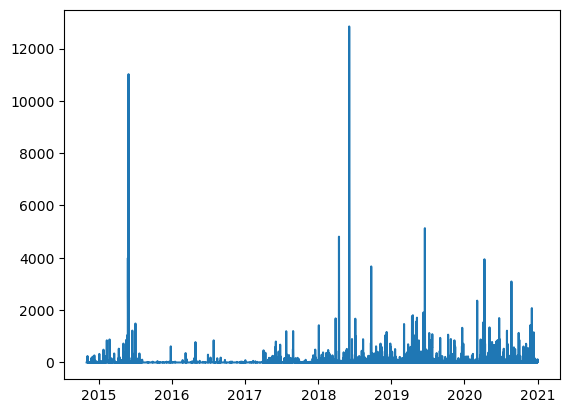

In [78]:
plt.plot(df_county['datetime'],df_county['customers_out'])

## Training using LSTM

In [79]:
WINDOW_SIZE = 20

In [80]:
"""
The entries of input_data will be WINDOW_SIZE consecutive entries of data
The entries of output_data will be the element that follows after the WINDOW_SIZE consecutive elements

For example if data = [0,1,2,3,4,5] and WINDOW_SIZE = 2 then
input_data      output_data
[[0,1],         [2,
[1,2],           3,
[2,3],           4,
[3,4]]           5]
"""

def data_to_input_and_output(data,target,features):
    input_data = []
    output_data = []

    for index in range(len(data)-WINDOW_SIZE):
        input_sample = data[features].iloc[index:index+WINDOW_SIZE]
        output_sample = data[target].iloc[index+WINDOW_SIZE]

        input_data.append(input_sample)
        output_data.append(output_sample)
    
    return np.array(input_data), np.array(output_data)

In [81]:
def lstm_model(X, y, epochs = 20, learning_rate=0.005):
    model = Sequential()
    model.add(InputLayer((WINDOW_SIZE,len(features))))
    model.add(LSTM(120))
    model.add(Dense(8,'relu'))
    model.add(Dense(1,'linear'))

    #check_point = ModelCheckpoint('model/checkpoint.keras', save_best_only=True, monitor='loss')

    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate), metrics=[RootMeanSquaredError()])
    model.fit(X, y, epochs= epochs, verbose=1)

    return model

In [82]:
tscv = TimeSeriesSplit()
pt = PowerTransformer()

metrics = []
train_pred = []
test_pred = []
time_indices = [] 

for i, (train_index, test_index) in enumerate(tscv.split(df_county)):
    df_train = df_county.iloc[train_index]
    df_test = df_county.iloc[test_index]

    pt.fit(df_train[features[:-1]])
    df_train_scaled = pd.DataFrame(pt.transform(df_train[features[:-1]]),columns=features[:-1])
    df_train_scaled['customers_out']=df_train['customers_out'].values

    df_test_scaled = pd.DataFrame(pt.transform(df_test[features[:-1]]),columns=features[:-1])
    df_test_scaled['customers_out']=df_test['customers_out'].values

    time_indices.append([train_index,test_index])

    train_input, train_output = data_to_input_and_output(df_train_scaled,'customers_out',features)
    test_input, test_output = data_to_input_and_output(df_test_scaled,'customers_out',features)

    model = lstm_model(train_input, train_output)

    metrics.append(model.get_metrics_result())
    print(f'Split #{i+1}')
    train_pred.append(model.predict(train_input))
    test_pred.append(model.predict(test_input))



Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 248861.5938 - root_mean_squared_error: 465.7557
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 289096.6250 - root_mean_squared_error: 496.1131
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 153197.6562 - root_mean_squared_error: 376.5108
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 49837.9414 - root_mean_squared_error: 205.9461
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 52653.0742 - root_mean_squared_error: 201.9700
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 33367.1641 - root_mean_squared_error: 145.1952
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 53353.1211 - root_mean_squared_error: 221.1785
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 77992.7969 - root_mean_squared_error: 257.6448
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 86490.1641 - root_mean_squared_error: 260.4117
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

In [83]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 120)            │        65,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 8)              │           968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,773 (776.46 KB)

 Trainable params: 66,257 (258.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 132,516 (517.64 KB)

## Predictions on training data

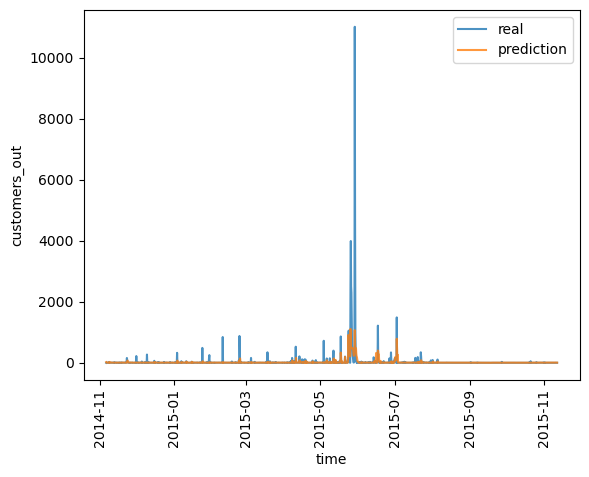

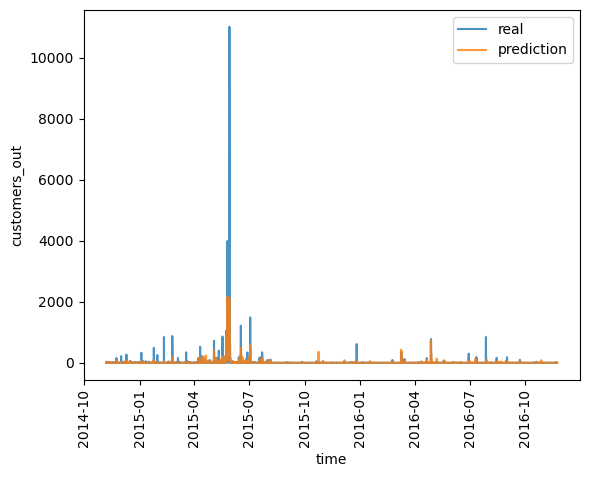

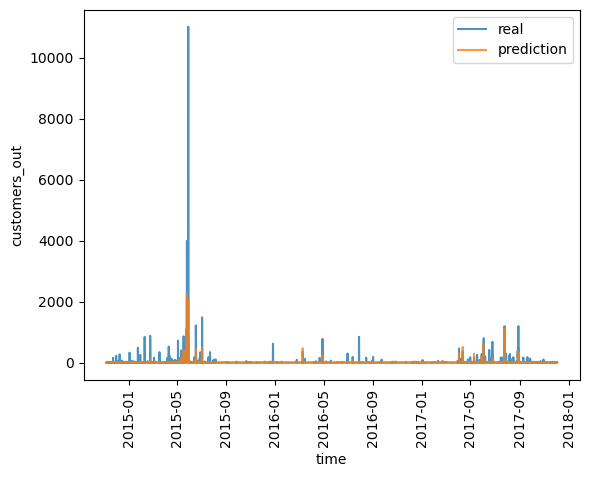

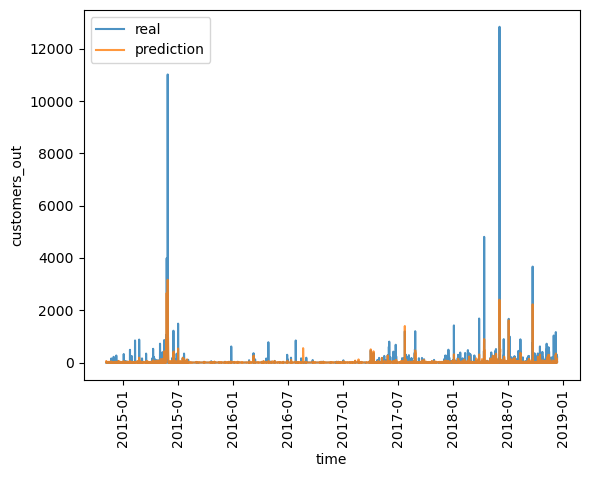

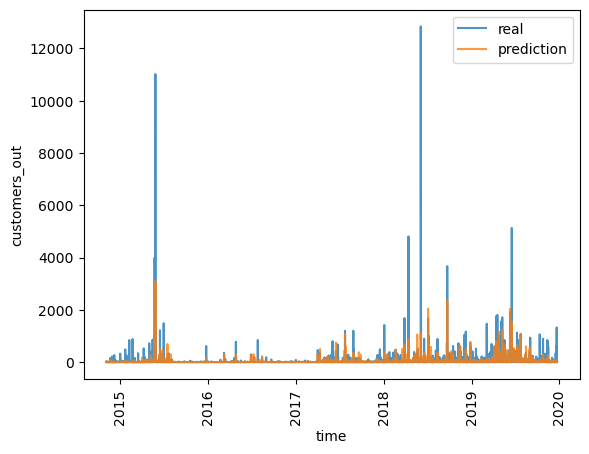

In [89]:
for i , x in enumerate(train_pred):
    fig, ax = plt.subplots()
    l2 = ax.plot(df_county['datetime'].iloc[time_indices[i][0][WINDOW_SIZE:]],df_county['customers_out'].iloc[time_indices[i][0][WINDOW_SIZE:]], label = 'real', alpha = 0.8)
    l1 = ax.plot(df_county['datetime'].iloc[time_indices[i][0][WINDOW_SIZE:]],x[:,0],label = 'prediction',alpha = 0.8)
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel('customers_out')
    plt.xticks(rotation=90)
    plt.show()

In [85]:
metrics

[{'loss': 100468.21875, 'root_mean_squared_error': 316.96722412109375},
 {'loss': 41647.55859375, 'root_mean_squared_error': 204.07733154296875},
 {'loss': 28836.1796875, 'root_mean_squared_error': 169.81219482421875},
 {'loss': 60350.37890625, 'root_mean_squared_error': 245.66314697265625},
 {'loss': 56109.99609375, 'root_mean_squared_error': 236.87548828125}]

## Predictions on test data

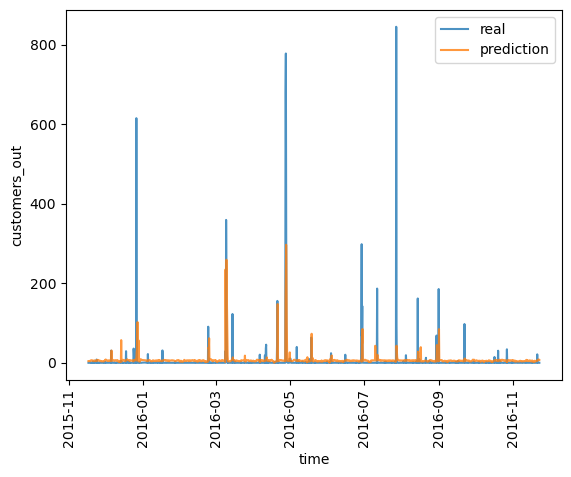

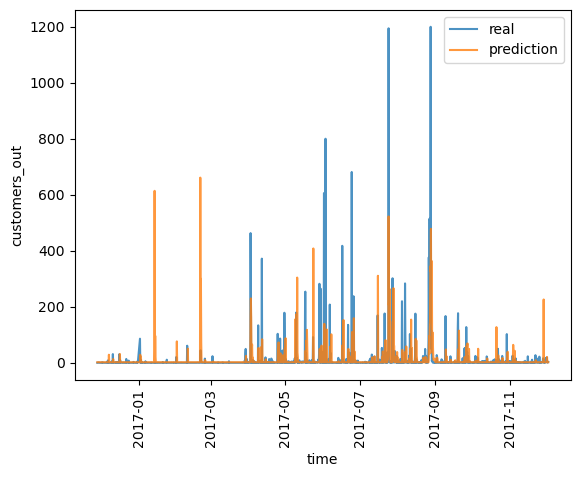

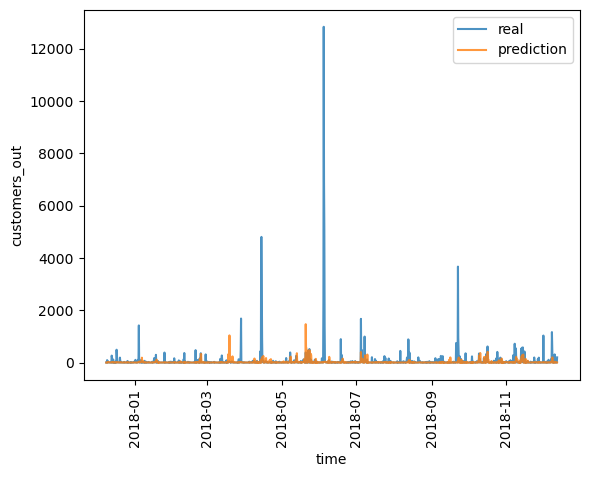

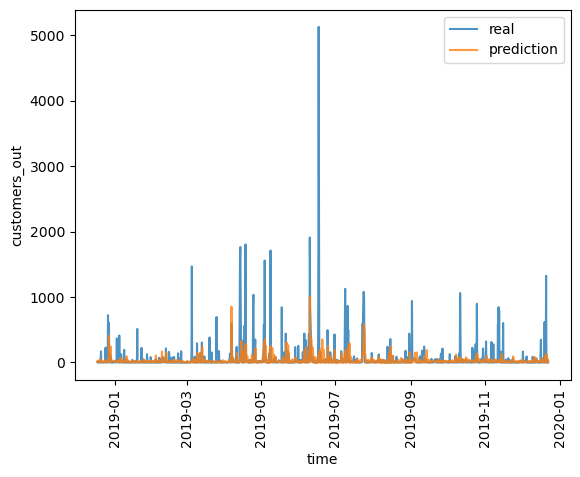

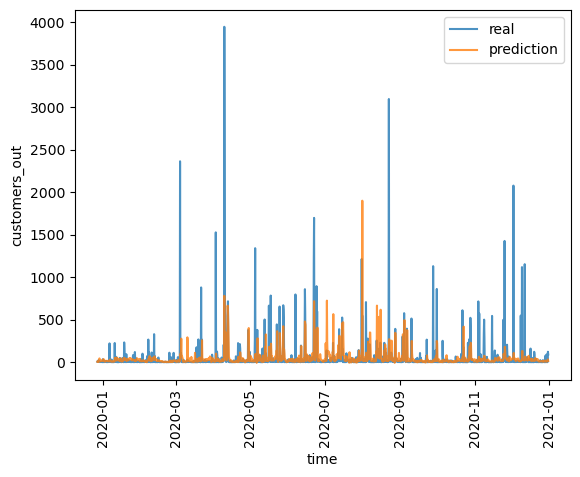

In [92]:
for i , x in enumerate(test_pred):
    fig, ax = plt.subplots()
    l2 = ax.plot(df_county['datetime'].iloc[time_indices[i][1][WINDOW_SIZE:]],df_county['customers_out'].iloc[time_indices[i][1][WINDOW_SIZE:]], label = 'real', alpha = 0.8)
    l1 = ax.plot(df_county['datetime'].iloc[time_indices[i][1][WINDOW_SIZE:]],x[:,0],label = 'prediction',alpha = 0.8)
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel('customers_out')
    plt.yscale('linear')
    plt.xticks(rotation=90)
    plt.show()

Add max of next 4 time entries.

Natural breaks to determine major/medium/minor outage.